# **INDONESIAN MEDICAL NER**

In [29]:
!pip install transformers datasets seqeval evaluate huggingface_hub -q

## Import Library

In [27]:
import random
import numpy as np
import torch
import json
from transformers import set_seed

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

set_seed(SEED)

## Load Dataset

In [28]:
INPUT_BASE_PATH = "/kaggle/input/datasets/faruqimhmmd/id-medical-ner"
OUTPUT_BASE_PATH = "/kaggle/working"

with open(f"{INPUT_BASE_PATH}/annotated.json", "r", encoding="utf-8") as f:
    data = json.load(f)

print(f"Total data: {len(data)}")

print("\nPreview 3 data pertama:")
for i, item in enumerate(data[:3]):
    print(f"\n--- Data {i+1} ---")
    print(f"Text: {item['text'][:100]}...")
    print(f"Annotations: {item['annotations']}")

Total data: 2240

Preview 3 data pertama:

--- Data 1 ---
Text: Halo Dokter, saya mau tanya soal vaksin BCG untuk anak. Anak saya baru lahir beberapa hari lalu, dan...
Annotations: [{'token': 'vaksin BCG', 'label': 'TINDAKAN'}, {'token': 'TBC', 'label': 'PENYAKIT'}]

--- Data 2 ---
Text: Halo Dok, saya perempuan usia 19 tahun, mau tanya soal kaki datar. Sejak kecil, saya perhatikan tela...
Annotations: [{'token': 'kaki datar', 'label': 'PENYAKIT'}, {'token': 'pegal', 'label': 'GEJALA'}, {'token': 'sakit', 'label': 'GEJALA'}]

--- Data 3 ---
Text: Alo, Dok, selamat siang. Saya laki-laki usia 23 tahun, mengalami kuku kaki tumbuh ke dalam setelah p...
Annotations: [{'token': 'kuku kaki tumbuh ke dalam', 'label': 'PENYAKIT'}, {'token': 'sakit', 'label': 'GEJALA'}, {'token': 'nanah', 'label': 'GEJALA'}]


## Handling MIssing Values

In [30]:
filtered = [item for item in data if len(item["annotations"]) > 0]

print(f"Total data setelah filter: {len(filtered)}")
print(f"Data dibuang: {len(data) - len(filtered)}")

Total data setelah filter: 2027
Data dibuang: 213


## Handling Duplicate Annotations

In [31]:
def dedup_annotations(annotations):
    seen_tokens = set()
    deduped = []
    for ann in annotations:
        if ann["token"] not in seen_tokens:
            seen_tokens.add(ann["token"])
            deduped.append(ann)
    return deduped

deduped_data = []
total_removed = 0

for item in filtered:
    original_count = len(item["annotations"])
    deduped_annotations = dedup_annotations(item["annotations"])
    removed = original_count - len(deduped_annotations)
    total_removed += removed
    deduped_data.append({
        "text": item["text"],
        "annotations": deduped_annotations,
        "url": item.get("url", "")
    })

print(f"Total data: {len(deduped_data)}")
print(f"Total duplikat token yang dibuang: {total_removed}")

Total data: 2027
Total duplikat token yang dibuang: 48


## Distribusi Label

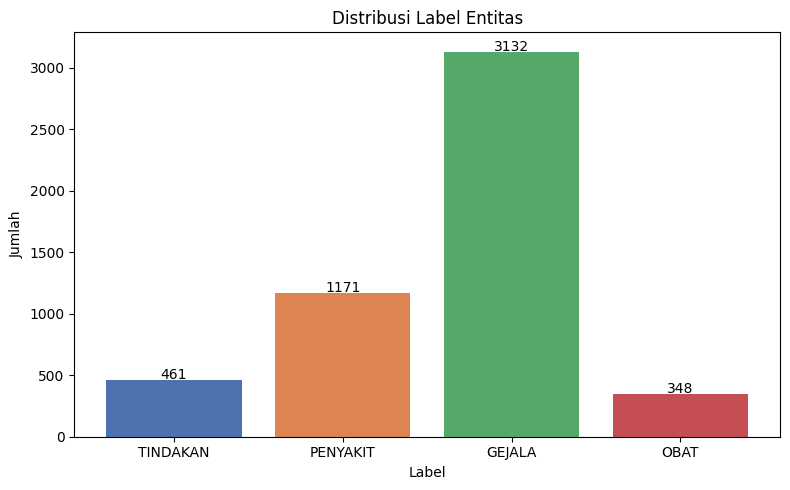

In [33]:
# Distribusi label di dataset
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

os.makedirs(f"{OUTPUT_BASE_PATH}/vis_img", exist_ok=True)

label_counter = Counter()
for item in filtered:
    for ann in item["annotations"]:
        label_counter[ann["label"]] += 1

labels = list(label_counter.keys())
counts = list(label_counter.values())

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, counts, color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"])
plt.title("Distribusi Label Entitas")
plt.xlabel("Label")
plt.ylabel("Jumlah")
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(count), ha="center")
plt.tight_layout()
plt.savefig(f"{OUTPUT_BASE_PATH}/vis_img/distribusi_label.png", dpi=150)
plt.show()

## Convert to BIO

In [34]:
def convert_to_bio(text, annotations):
    tokens = text.split()
    labels = ["O"] * len(tokens)

    for ann in annotations:
        ann_tokens = ann["token"].split()
        label = ann["label"]

        # cari posisi token entitas di dalam teks
        for i in range(len(tokens)):
            if tokens[i:i+len(ann_tokens)] == ann_tokens:
                labels[i] = f"B-{label}"
                for j in range(1, len(ann_tokens)):
                    labels[i+j] = f"I-{label}"


    return list(zip(tokens, labels))

bio_data = []
for item in deduped_data:
    bio = convert_to_bio(item["text"], item["annotations"])
    bio_data.append(bio)

# preview hasil konversi
print("Contoh hasil konversi BIO:")
for token, label in bio_data[0]:
    print(f"{token}\t{label}")

Contoh hasil konversi BIO:
Halo	O
Dokter,	O
saya	O
mau	O
tanya	O
soal	O
vaksin	B-TINDAKAN
BCG	I-TINDAKAN
untuk	O
anak.	O
Anak	O
saya	O
baru	O
lahir	O
beberapa	O
hari	O
lalu,	O
dan	O
saya	O
masih	O
bingung	O
kapan	O
waktu	O
yang	O
paling	O
tepat	O
untuk	O
pemberian	O
vaksin	B-TINDAKAN
BCG	I-TINDAKAN
(TBC).	O
Apakah	O
harus	O
langsung	O
setelah	O
lahir,	O
atau	O
bisa	O
ditunda?	O
Mohon	O
penjelasannya,	O
ya	O
Dok.	O


## Distribusi BIO

Distribusi BIO Label di Train Set:
  B-GEJALA: 1460
  B-OBAT: 243
  B-PENYAKIT: 785
  B-TINDAKAN: 300
  I-GEJALA: 962
  I-OBAT: 176
  I-PENYAKIT: 432
  I-TINDAKAN: 215
  O: 53249


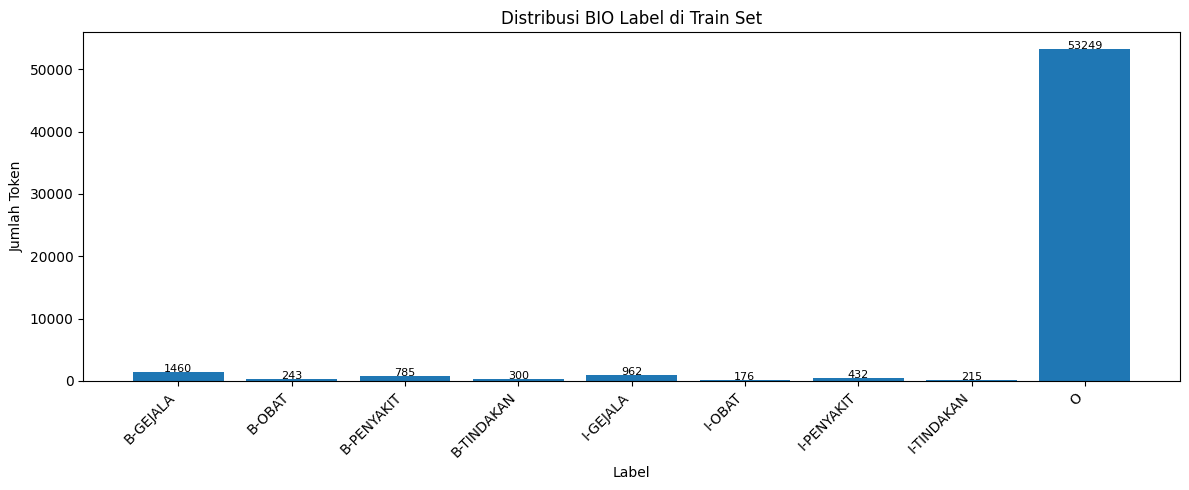

In [45]:
# Distribusi BIO label di train set
bio_counter = Counter()
for sentence in train_data:
    for _, label in sentence:
        bio_counter[label] += 1

print("Distribusi BIO Label di Train Set:")
for label, count in sorted(bio_counter.items()):
    print(f"  {label}: {count}")

sorted_labels = sorted(bio_counter.keys())
sorted_counts = [bio_counter[l] for l in sorted_labels]

plt.figure(figsize=(12, 5))
bars = plt.bar(sorted_labels, sorted_counts)
plt.title("Distribusi BIO Label di Train Set")
plt.xlabel("Label")
plt.ylabel("Jumlah Token")
plt.xticks(rotation=45, ha="right")
for bar, count in zip(bars, sorted_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(count), ha="center", fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUTPUT_BASE_PATH}/vis_img/distribusi_bio_label.png", dpi=150)
plt.show()

## Train Test Split

In [4]:
import random

random.shuffle(bio_data)

total = len(bio_data)
train_end = int(total * 0.7)
dev_end = int(total * 0.85)

train_data = bio_data[:train_end]
dev_data = bio_data[train_end:dev_end]
test_data = bio_data[dev_end:]

print(f"Total data: {total}")
print(f"Train: {len(train_data)}")
print(f"Dev: {len(dev_data)}")
print(f"Test: {len(test_data)}")

Total data: 2027
Train: 1418
Dev: 304
Test: 305


In [5]:
import os

os.makedirs(f"{OUTPUT_BASE_PATH}/data/bio", exist_ok=True)

def save_bio(data, filepath):
    with open(filepath, "w", encoding="utf-8") as f:
        for sentence in data:
            for token, label in sentence:
                f.write(f"{token}\t{label}\n")
            f.write("\n")  # baris kosong sebagai pemisah antar kalimat
    print(f"Saved {len(data)} sentences to {filepath}")

save_bio(train_data, f"{OUTPUT_BASE_PATH}/data/bio/train.txt")
save_bio(dev_data, f"{OUTPUT_BASE_PATH}/data/bio/dev.txt")
save_bio(test_data, f"{OUTPUT_BASE_PATH}/data/bio/test.txt")

Saved 1418 sentences to /kaggle/working/data/bio/train.txt
Saved 304 sentences to /kaggle/working/data/bio/dev.txt
Saved 305 sentences to /kaggle/working/data/bio/test.txt


In [8]:
from datasets import Dataset
import pandas as pd

def read_bio_file(filepath):
    sentences = []
    tokens = []
    labels = []

    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line == "":
                if tokens:
                    sentences.append({"tokens": tokens, "labels": labels})
                    tokens = []
                    labels = []
            else:
                parts = line.split("\t")
                if len(parts) == 2:
                    tokens.append(parts[0])
                    labels.append(parts[1])

    if tokens:
        sentences.append({"tokens": tokens, "labels": labels})

    return sentences

train_sentences = read_bio_file(f"{OUTPUT_BASE_PATH}/data/bio/train.txt")
dev_sentences = read_bio_file(f"{OUTPUT_BASE_PATH}/data/bio/dev.txt")
test_sentences = read_bio_file(f"{OUTPUT_BASE_PATH}/data/bio/test.txt")

print(f"Train: {len(train_sentences)} sentences")
print(f"Dev: {len(dev_sentences)} sentences")
print(f"Test: {len(test_sentences)} sentences")

# preview
print("\nContoh data pertama:")
print("Tokens:", train_sentences[0]["tokens"][:10])
print("Labels:", train_sentences[0]["labels"][:10])

Train: 1418 sentences
Dev: 304 sentences
Test: 305 sentences

Contoh data pertama:
Tokens: ['Halo,', 'Dokter,', 'mau', 'tanya', 'soal', 'phobia.', 'Saya', 'perempuan', 'usia', '29']
Labels: ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']


In [9]:
from transformers import AutoTokenizer

# definisi semua label
label_list = [
    "O",
    "B-GEJALA", "I-GEJALA",
    "B-PENYAKIT", "I-PENYAKIT",
    "B-OBAT", "I-OBAT",
    "B-TINDAKAN", "I-TINDAKAN"
]

label2id = {label: i for i, label in enumerate(label_list)}
id2label = {i: label for i, label in enumerate(label_list)}

print(f"Total label: {len(label_list)}")
print(label2id)

# load tokenizer IndoBERT
MODEL_NAME = "indobenchmark/indobert-base-p1"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"\nTokenizer loaded: {MODEL_NAME}")

Total label: 9
{'O': 0, 'B-GEJALA': 1, 'I-GEJALA': 2, 'B-PENYAKIT': 3, 'I-PENYAKIT': 4, 'B-OBAT': 5, 'I-OBAT': 6, 'B-TINDAKAN': 7, 'I-TINDAKAN': 8}


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]


Tokenizer loaded: indobenchmark/indobert-base-p1


In [10]:
def tokenize_and_align_labels(sentences, tokenizer, label2id, max_length=128):
    tokenized_inputs = []

    for sentence in sentences:
        tokens = sentence["tokens"]
        labels = sentence["labels"]

        tokenized = tokenizer(
            tokens,
            is_split_into_words=True,
            max_length=max_length,
            truncation=True,
            padding="max_length"
        )

        word_ids = tokenized.word_ids()
        aligned_labels = []
        previous_word_idx = None

        for word_idx in word_ids:
            if word_idx is None:
                aligned_labels.append(-100)  # special tokens diabaikan
            elif word_idx != previous_word_idx:
                aligned_labels.append(label2id[labels[word_idx]])
            else:
                # subword token, pakai I- label atau -100
                label = labels[word_idx]
                if label.startswith("B-"):
                    aligned_labels.append(label2id["I-" + label[2:]])
                else:
                    aligned_labels.append(label2id[label])
            previous_word_idx = word_idx

        tokenized["labels"] = aligned_labels
        tokenized_inputs.append(tokenized)

    return tokenized_inputs

train_tokenized = tokenize_and_align_labels(train_sentences, tokenizer, label2id)
dev_tokenized = tokenize_and_align_labels(dev_sentences, tokenizer, label2id)
test_tokenized = tokenize_and_align_labels(test_sentences, tokenizer, label2id)

print(f"Train tokenized: {len(train_tokenized)}")
print(f"Dev tokenized: {len(dev_tokenized)}")
print(f"Test tokenized: {len(test_tokenized)}")

# preview
print("\nContoh input_ids[:10]:", train_tokenized[0]["input_ids"][:10])
print("Contoh labels[:10]:", train_tokenized[0]["labels"][:10])

Train tokenized: 1418
Dev tokenized: 304
Test tokenized: 305

Contoh input_ids[:10]: [2, 1, 30468, 1, 30468, 422, 3001, 1495, 20662, 16144]
Contoh labels[:10]: [-100, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [11]:
import torch
from torch.utils.data import Dataset

class NERDataset(Dataset):
    def __init__(self, tokenized_inputs):
        self.inputs = tokenized_inputs

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return {
            "input_ids": torch.tensor(self.inputs[idx]["input_ids"]),
            "attention_mask": torch.tensor(self.inputs[idx]["attention_mask"]),
            "labels": torch.tensor(self.inputs[idx]["labels"])
        }

train_dataset = NERDataset(train_tokenized)
dev_dataset = NERDataset(dev_tokenized)
test_dataset = NERDataset(test_tokenized)

print(f"Train dataset: {len(train_dataset)}")
print(f"Dev dataset: {len(dev_dataset)}")
print(f"Test dataset: {len(test_dataset)}")

Train dataset: 1418
Dev dataset: 304
Test dataset: 305


In [13]:
from transformers import AutoModelForTokenClassification, AutoConfig

config = AutoConfig.from_pretrained(MODEL_NAME)
config.hidden_dropout_prob = 0.2
config.attention_probs_dropout_prob = 0.2
config.num_labels = len(label_list)
config.id2label = id2label
config.label2id = label2id

model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    config=config
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(f"Model loaded: {MODEL_NAME}")
print(f"Device: {device}")
print(f"Total labels: {len(label_list)}")

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Model loaded: indobenchmark/indobert-base-p1
Device: cuda
Total labels: 9


In [15]:
from transformers import TrainingArguments, Trainer, DataCollatorForTokenClassification, EarlyStoppingCallback
import evaluate
import numpy as np

seqeval = evaluate.load("seqeval")

def compute_metrics(eval_preds):
    logits, labels = eval_preds
    predictions = np.argmax(logits, axis=-1)

    true_labels = [
        [id2label[l] for l in label if l != -100]
        for label in labels
    ]
    true_predictions = [
        [id2label[p] for p, l in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    results = seqeval.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"]
    }

data_collator = DataCollatorForTokenClassification(tokenizer)

training_args = TrainingArguments(
    learning_rate=3e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=10,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    eval_strategy="steps",
    save_strategy="steps",
    eval_steps=100,
    save_steps=100,
    logging_strategy="steps",
    logging_steps=10,
    save_total_limit=1,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("Trainer ready")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Trainer ready


In [16]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Step,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
100,0.273649,0.251952,0.434109,0.564706,0.490869,0.953882
200,0.188587,0.205080,0.535065,0.692437,0.603663,0.960385
300,0.131165,0.210196,0.571823,0.695798,0.627748,0.962376
400,0.085657,0.231980,0.596264,0.697479,0.642912,0.963902
500,0.059875,0.248569,0.570833,0.690756,0.625095,0.961248
600,0.061261,0.280217,0.586630,0.722689,0.647590,0.962774
700,0.031898,0.287516,0.593705,0.697479,0.641422,0.963769
800,0.027669,0.293271,0.601439,0.702521,0.648062,0.964366


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=890, training_loss=0.19767091466804568, metrics={'train_runtime': 297.4698, 'train_samples_per_second': 47.669, 'train_steps_per_second': 2.992, 'total_flos': 926355624791040.0, 'train_loss': 0.19767091466804568, 'epoch': 10.0})

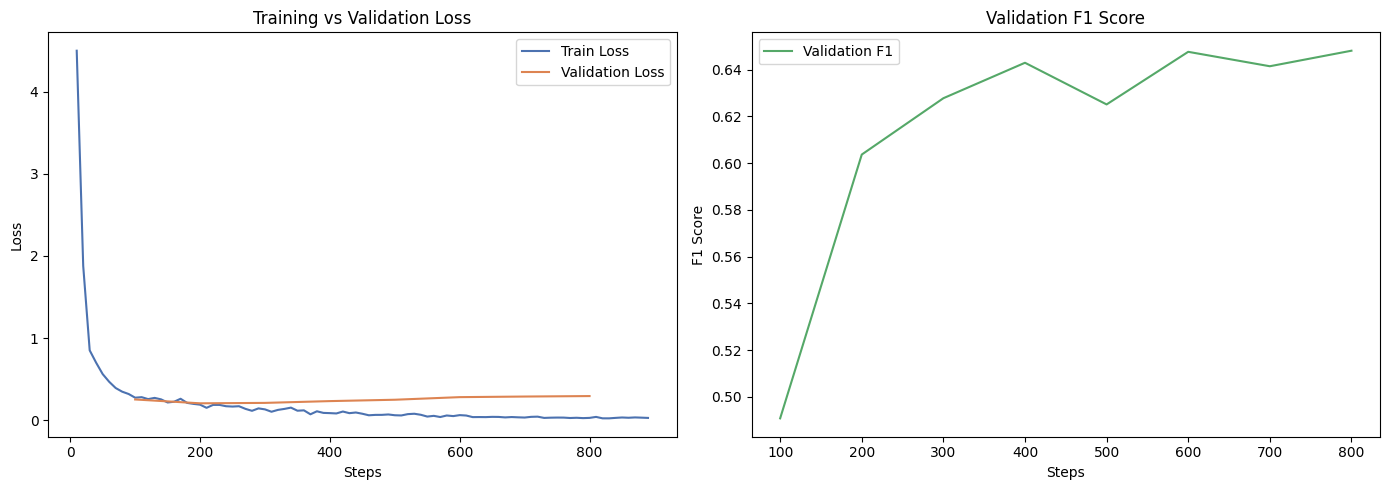

In [46]:
# Training & Validation Loss curve
log_history = trainer.state.log_history

train_steps, train_losses = [], []
eval_steps, eval_losses, eval_f1s = [], [], []

for log in log_history:
    if "loss" in log and "eval_loss" not in log:
        train_steps.append(log["step"])
        train_losses.append(log["loss"])
    if "eval_loss" in log:
        eval_steps.append(log["step"])
        eval_losses.append(log["eval_loss"])
        if "eval_f1" in log:
            eval_f1s.append(log["eval_f1"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_steps, train_losses, label="Train Loss", color="#4C72B0")
axes[0].plot(eval_steps, eval_losses, label="Validation Loss", color="#DD8452")
axes[0].set_title("Training vs Validation Loss")
axes[0].set_xlabel("Steps")
axes[0].set_ylabel("Loss")
axes[0].legend()

if eval_f1s:
    axes[1].plot(eval_steps, eval_f1s, label="Validation F1", color="#55A868")
    axes[1].set_title("Validation F1 Score")
    axes[1].set_xlabel("Steps")
    axes[1].set_ylabel("F1 Score")
    axes[1].legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_BASE_PATH}/vis_img/training_curves.png", dpi=150)
plt.show()

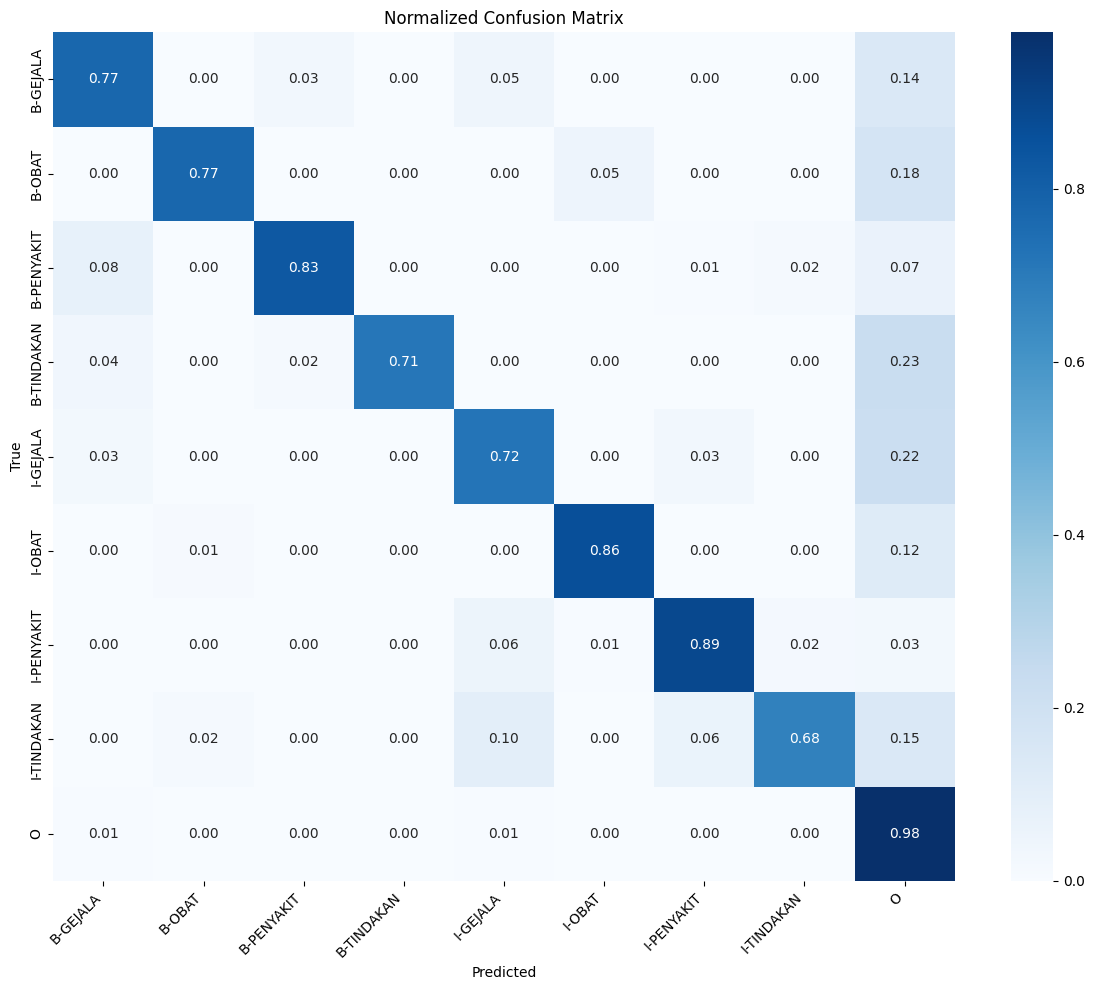

In [47]:
# Confusion matrix heatmap per label
from sklearn.metrics import confusion_matrix

all_true, all_pred = [], []

model.eval()
with torch.no_grad():
    for batch in torch.utils.data.DataLoader(test_dataset, batch_size=16):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels_batch = batch["labels"].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=-1)
        for pred_seq, label_seq in zip(preds, labels_batch):
            for p, l in zip(pred_seq, label_seq):
                if l.item() != -100:
                    all_true.append(id2label[l.item()])
                    all_pred.append(id2label[p.item()])

unique_labels = sorted(set(all_true + all_pred))
cm = confusion_matrix(all_true, all_pred, labels=unique_labels)
cm_normalized = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", xticklabels=unique_labels,
            yticklabels=unique_labels, cmap="Blues")
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{OUTPUT_BASE_PATH}/vis_img/confusion_matrix.png", dpi=150)
plt.show()

In [19]:
import numpy as np
import pandas as pd
from seqeval.metrics import (
    classification_report,
    f1_score,
    precision_score,
    recall_score
)

# ============================
# Predict on test set
# ============================
predictions, labels, metrics = trainer.predict(test_dataset)

# Ambil label dengan probabilitas tertinggi
predictions = np.argmax(predictions, axis=2)

# ============================
# Convert ids -> labels
# ============================
true_labels = []
pred_labels = []

for pred, label in zip(predictions, labels):
    true_label = []
    pred_label = []

    for p, l in zip(pred, label):
        # Ignore special tokens
        if l != -100:
            true_label.append(id2label[l])
            pred_label.append(id2label[p])

    true_labels.append(true_label)
    pred_labels.append(pred_label)

# ============================
# Overall Metrics
# ============================
print("="*60)
print("OVERALL METRICS")
print("="*60)

print(f"Precision : {precision_score(true_labels, pred_labels):.4f}")
print(f"Recall    : {recall_score(true_labels, pred_labels):.4f}")
print(f"F1 Score  : {f1_score(true_labels, pred_labels):.4f}")

# ============================
# Classification Report
# ============================
print("\n")
print("="*60)
print("CLASSIFICATION REPORT")
print("="*60)

print(
    classification_report(
        true_labels,
        pred_labels,
        digits=4
    )
)

# ============================
# Per-label dataframe
# ============================
report_dict = classification_report(
    true_labels,
    pred_labels,
    output_dict=True
)

report_df = (
    pd.DataFrame(report_dict)
    .transpose()
    .round(4)
)

print("\n")
print("="*60)
print("REPORT DATAFRAME")
print("="*60)
display(report_df)

# ============================
# Show examples of prediction
# ============================
print("\n")
print("="*60)
print("SAMPLE PREDICTIONS")
print("="*60)

for i in range(5):
    print(f"\n===== Sample {i+1} =====")

    for t, p in zip(true_labels[i], pred_labels[i]):
        if t != "O" or p != "O":
            print(f"True: {t:15} | Pred: {p}")

print("\n")
print("="*60)
print(f"Total Errors: {len(error_df)}")
print("="*60)

display(error_df.head(30))

OVERALL METRICS
Precision : 0.6576
Recall    : 0.7388
F1 Score  : 0.6958


CLASSIFICATION REPORT
              precision    recall  f1-score   support

      GEJALA     0.6244    0.7216    0.6694       334
        OBAT     0.6562    0.7368    0.6942        57
    PENYAKIT     0.7396    0.8023    0.7696       177
    TINDAKAN     0.6102    0.6429    0.6261        56

   micro avg     0.6576    0.7388    0.6958       624
   macro avg     0.6576    0.7259    0.6898       624
weighted avg     0.6587    0.7388    0.6962       624



REPORT DATAFRAME


,precision,recall,f1-score,support
GEJALA,0.6244,0.7216,0.6694,334.0
OBAT,0.6562,0.7368,0.6942,57.0
PENYAKIT,0.7396,0.8023,0.7696,177.0
TINDAKAN,0.6102,0.6429,0.6261,56.0
micro avg,0.6576,0.7388,0.6958,624.0
macro avg,0.6576,0.7259,0.6898,624.0
weighted avg,0.6587,0.7388,0.6962,624.0




SAMPLE PREDICTIONS

===== Sample 1 =====
True: O               | Pred: I-GEJALA
True: B-GEJALA        | Pred: I-GEJALA
True: B-GEJALA        | Pred: B-GEJALA

===== Sample 2 =====
True: B-TINDAKAN      | Pred: B-TINDAKAN
True: B-TINDAKAN      | Pred: B-TINDAKAN
True: B-TINDAKAN      | Pred: B-TINDAKAN
True: O               | Pred: B-GEJALA

===== Sample 3 =====
True: B-TINDAKAN      | Pred: B-TINDAKAN
True: B-PENYAKIT      | Pred: I-TINDAKAN
True: I-PENYAKIT      | Pred: I-TINDAKAN
True: I-PENYAKIT      | Pred: I-TINDAKAN

===== Sample 4 =====
True: B-TINDAKAN      | Pred: B-TINDAKAN
True: I-TINDAKAN      | Pred: I-TINDAKAN
True: B-TINDAKAN      | Pred: B-TINDAKAN
True: I-TINDAKAN      | Pred: I-TINDAKAN

===== Sample 5 =====
True: B-TINDAKAN      | Pred: B-TINDAKAN
True: I-TINDAKAN      | Pred: I-TINDAKAN
True: B-TINDAKAN      | Pred: B-TINDAKAN
True: I-TINDAKAN      | Pred: I-TINDAKAN


Total Errors: 525


,True,Pred
0,O,I-GEJALA
1,B-GEJALA,I-GEJALA
2,O,B-GEJALA
3,B-PENYAKIT,I-TINDAKAN
4,I-PENYAKIT,I-TINDAKAN
5,I-PENYAKIT,I-TINDAKAN
6,O,B-TINDAKAN
7,O,I-TINDAKAN
8,B-OBAT,O
9,I-OBAT,O


In [21]:
trainer.save_model("/kaggle/working/best_model")
tokenizer.save_pretrained("/kaggle/working/best_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/kaggle/working/best_model/tokenizer_config.json',
 '/kaggle/working/best_model/tokenizer.json')

In [42]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")

login(hf_token)

In [44]:
model.push_to_hub("mfaruqi/indonesian-medical-ner")
tokenizer.push_to_hub("mfaruqi/indonesian-medical-ner")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md: 0.00B [00:00, ?B/s]

CommitInfo(commit_url='https://huggingface.co/mfaruqi/indonesian-medical-ner/commit/3975b9d35c858d39e18d7793fbd164a364d03ac9', commit_message='Upload tokenizer', commit_description='', oid='3975b9d35c858d39e18d7793fbd164a364d03ac9', pr_url=None, repo_url=RepoUrl('https://huggingface.co/mfaruqi/indonesian-medical-ner', endpoint='https://huggingface.co', repo_type='model', repo_id='mfaruqi/indonesian-medical-ner'), pr_revision=None, pr_num=None)